In [1]:
from tabicl import TabICLClassifier
import nnsight
import matplotlib.pyplot as plt

/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import pandas as pd
from huggingface_hub import hf_hub_download
from torch.utils.data import Dataset, DataLoader


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:
sonar_dataset = pd.read_csv(
    hf_hub_download('mnemoraorg/sonar-rock-mine','raw_sonar.csv',repo_type="dataset"),
    header = None
)
sonar_dataset

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
203,0.0187,0.0346,0.0168,0.0177,0.0393,0.1630,0.2028,0.1694,0.2328,0.2684,...,0.0116,0.0098,0.0199,0.0033,0.0101,0.0065,0.0115,0.0193,0.0157,M
204,0.0323,0.0101,0.0298,0.0564,0.0760,0.0958,0.0990,0.1018,0.1030,0.2154,...,0.0061,0.0093,0.0135,0.0063,0.0063,0.0034,0.0032,0.0062,0.0067,M
205,0.0522,0.0437,0.0180,0.0292,0.0351,0.1171,0.1257,0.1178,0.1258,0.2529,...,0.0160,0.0029,0.0051,0.0062,0.0089,0.0140,0.0138,0.0077,0.0031,M
206,0.0303,0.0353,0.0490,0.0608,0.0167,0.1354,0.1465,0.1123,0.1945,0.2354,...,0.0086,0.0046,0.0126,0.0036,0.0035,0.0034,0.0079,0.0036,0.0048,M


In [5]:
# Let's shuffle it
sonar_dataset = sonar_dataset.sample(frac=1.0, random_state=2806)

In [6]:
sonar_dataset

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
67,0.0368,0.0403,0.0317,0.0293,0.0820,0.1342,0.1161,0.0663,0.0155,0.0506,...,0.0091,0.0160,0.0160,0.0081,0.0070,0.0135,0.0067,0.0078,0.0068,R
182,0.0095,0.0308,0.0539,0.0411,0.0613,0.1039,0.1016,0.1394,0.2592,0.3745,...,0.0181,0.0019,0.0102,0.0133,0.0040,0.0042,0.0030,0.0031,0.0033,M
117,0.0228,0.0106,0.0130,0.0842,0.1117,0.1506,0.1776,0.0997,0.1428,0.2227,...,0.0098,0.0178,0.0077,0.0074,0.0095,0.0055,0.0045,0.0063,0.0039,M
157,0.0201,0.0178,0.0274,0.0232,0.0724,0.0833,0.1232,0.1298,0.2085,0.2720,...,0.0131,0.0049,0.0104,0.0102,0.0092,0.0083,0.0020,0.0048,0.0036,M
106,0.0331,0.0423,0.0474,0.0818,0.0835,0.0756,0.0374,0.0961,0.0548,0.0193,...,0.0078,0.0174,0.0176,0.0038,0.0129,0.0066,0.0044,0.0134,0.0092,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,0.0180,0.0444,0.0476,0.0698,0.1615,0.0887,0.0596,0.1071,0.3175,0.2918,...,0.0122,0.0114,0.0098,0.0027,0.0025,0.0026,0.0050,0.0073,0.0022,M
58,0.0225,0.0019,0.0075,0.0097,0.0445,0.0906,0.0889,0.0655,0.1624,0.1452,...,0.0034,0.0129,0.0100,0.0044,0.0057,0.0030,0.0035,0.0021,0.0027,R
141,0.0707,0.1252,0.1447,0.1644,0.1693,0.0844,0.0715,0.0947,0.1583,0.1247,...,0.0156,0.0197,0.0135,0.0127,0.0138,0.0133,0.0131,0.0154,0.0218,M
49,0.0119,0.0582,0.0623,0.0600,0.1397,0.1883,0.1422,0.1447,0.0487,0.0864,...,0.0025,0.0103,0.0074,0.0123,0.0069,0.0076,0.0073,0.0030,0.0138,R


In [7]:
# Let's convert the labels to 0/1
sonar_dataset['bin_labels'] = (sonar_dataset[60]=='M') * 1.0
sonar_dataset

,0,1,2,3,4,5,6,7,8,9,...,52,53,54,55,56,57,58,59,60,bin_labels
67,0.0368,0.0403,0.0317,0.0293,0.0820,0.1342,0.1161,0.0663,0.0155,0.0506,...,0.0160,0.0160,0.0081,0.0070,0.0135,0.0067,0.0078,0.0068,R,0.0
182,0.0095,0.0308,0.0539,0.0411,0.0613,0.1039,0.1016,0.1394,0.2592,0.3745,...,0.0019,0.0102,0.0133,0.0040,0.0042,0.0030,0.0031,0.0033,M,1.0
117,0.0228,0.0106,0.0130,0.0842,0.1117,0.1506,0.1776,0.0997,0.1428,0.2227,...,0.0178,0.0077,0.0074,0.0095,0.0055,0.0045,0.0063,0.0039,M,1.0
157,0.0201,0.0178,0.0274,0.0232,0.0724,0.0833,0.1232,0.1298,0.2085,0.2720,...,0.0049,0.0104,0.0102,0.0092,0.0083,0.0020,0.0048,0.0036,M,1.0
106,0.0331,0.0423,0.0474,0.0818,0.0835,0.0756,0.0374,0.0961,0.0548,0.0193,...,0.0174,0.0176,0.0038,0.0129,0.0066,0.0044,0.0134,0.0092,M,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,0.0180,0.0444,0.0476,0.0698,0.1615,0.0887,0.0596,0.1071,0.3175,0.2918,...,0.0114,0.0098,0.0027,0.0025,0.0026,0.0050,0.0073,0.0022,M,1.0
58,0.0225,0.0019,0.0075,0.0097,0.0445,0.0906,0.0889,0.0655,0.1624,0.1452,...,0.0129,0.0100,0.0044,0.0057,0.0030,0.0035,0.0021,0.0027,R,0.0
141,0.0707,0.1252,0.1447,0.1644,0.1693,0.0844,0.0715,0.0947,0.1583,0.1247,...,0.0197,0.0135,0.0127,0.0138,0.0133,0.0131,0.0154,0.0218,M,1.0
49,0.0119,0.0582,0.0623,0.0600,0.1397,0.1883,0.1422,0.1447,0.0487,0.0864,...,0.0103,0.0074,0.0123,0.0069,0.0076,0.0073,0.0030,0.0138,R,0.0


In [8]:
train_size = sonar_dataset.shape[0] // 10 * 7
dev_size = sonar_dataset.shape[0] // 20 * 3
test_size = sonar_dataset.shape[0] - train_size - dev_size
train_size, dev_size, test_size

(140, 30, 38)

In [9]:
train_features = sonar_dataset.iloc[:train_size,:60]
train_labels = sonar_dataset.iloc[:train_size,61]
dev_features = sonar_dataset.iloc[train_size:train_size + dev_size,:60]
dev_labels = sonar_dataset.iloc[train_size:train_size+dev_size,61]
test_features = sonar_dataset.iloc[train_size+dev_size:,:60]
test_labels = sonar_dataset.iloc[train_size+dev_size:,61]

In [10]:
clf = TabICLClassifier(nnsight=True)

In [11]:
# clf.fit(train_features, train_labels)


In [12]:
# preds = clf.predict(dev_features)
# preds

In [13]:
# dev_labels[16]

In [14]:
# tp,fp,tn, fn = 0, 0, 0, 0
# for i,key in enumerate(dev_labels.keys()):
#     # print(f"Prediction: {preds[i]}\tLabel: {dev_labels[key]}")
#     if preds[i] == 1.0 and dev_labels[key] == 1.0: tp += 1
#     if preds[i] == 1.0 and dev_labels[key] == 0.0: fp += 1
#     if preds[i] == 0.0 and dev_labels[key] == 1.0: fn += 1
#     if preds[i] == 0.0 and dev_labels[key] == 0.0: tn += 1
# print(f"Tot instances: {i+1}\tTP: {tp}\tFP: {fp}\tFN: {fn}\tTN: {tn}")



In [15]:
clf.fit(train_features, train_labels)

tracer, X_test_t = clf.get_tracer(dev_features, estimator_idx=0)

with tracer.trace(X_test_t):
    col_emb = tracer.model.col_embedder.output.save()
    row_rep  = tracer.model.row_interactor.output.save()
    out      = tracer.output.save()

print(col_emb.shape)  # (1, train+test, n_features, 128)
print(row_rep.shape)  # (1, train+test, 512)
print(out.shape)      # (1, 30, 2)  — test samples × classes

torch.Size([1, 170, 64, 128])
torch.Size([1, 170, 512])
torch.Size([1, 30, 2])


In [16]:
feature_id = 4 # Note: the first colums are reserved for the CLS tokens, so they are constant across rows
this_feature_embeddings = col_emb[0,:,feature_id,:]
this_feature_embeddings.shape

torch.Size([170, 128])

In [17]:
this_feature_embeddings

tensor([[ 1.1055, -1.4414, -0.4778,  ...,  0.0696, -0.6055,  1.1484],
        [ 1.2520, -1.5684, -0.7568,  ...,  0.0903, -0.8413,  1.0322],
        [ 1.2197, -1.8047, -0.9565,  ...,  0.2446, -0.8325,  0.9707],
        ...,
        [ 1.2354, -1.7783, -0.9639,  ...,  0.1384, -0.8252,  0.9590],
        [ 1.2188, -1.4355, -0.5879,  ...,  0.1614, -0.7710,  1.1133],
        [ 1.2246, -1.4863, -0.7129,  ...,  0.0886, -0.9238,  1.0332]],
       device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)

In [18]:
this_feature_norms = this_feature_embeddings.norm(dim=1)
this_feature_norms


tensor([11.5312, 11.6250, 11.6094, 11.5703, 11.6406, 11.5938, 11.6250, 11.6250,
        11.6016, 11.6016, 11.5234, 11.6641, 11.6484, 11.5391, 11.6250, 11.6641,
        11.6250, 11.6484, 11.5938, 11.6406, 11.6562, 11.6484, 11.6328, 11.6328,
        11.6406, 11.5469, 11.6328, 11.5703, 11.5625, 11.6406, 11.5156, 11.6094,
        11.6562, 11.6016, 11.6328, 11.6250, 11.6016, 11.5234, 11.5312, 11.5391,
        11.6172, 11.6250, 11.5312, 11.6250, 11.5703, 11.6172, 11.6094, 11.5156,
        11.6172, 11.6016, 11.5625, 11.5156, 11.6328, 11.6094, 11.6406, 11.6172,
        11.6172, 11.6328, 11.6250, 11.6172, 11.6406, 11.6172, 11.6172, 11.6484,
        11.6484, 11.6094, 11.6484, 11.6328, 11.6328, 11.6484, 11.5312, 11.6406,
        11.5859, 11.5625, 11.5859, 11.6172, 11.5547, 11.6328, 11.6406, 11.5938,
        11.5938, 11.6406, 11.5938, 11.6172, 11.6562, 11.5547, 11.5234, 11.5391,
        11.5938, 11.6250, 11.6484, 11.5938, 11.6250, 11.6484, 11.6094, 11.6172,
        11.6562, 11.5234, 11.5312, 11.64

In [19]:
U, S, Vt = torch.linalg.svd(this_feature_embeddings.to(float), full_matrices=False)
S

tensor([1.4817e+02, 2.7272e+01, 1.1482e+01, 5.9881e+00, 4.3457e+00, 2.5630e+00,
        1.8075e+00, 1.4526e+00, 1.1061e+00, 1.0162e+00, 7.6970e-01, 6.5891e-01,
        5.9965e-01, 5.8373e-01, 4.7936e-01, 4.1753e-01, 3.8897e-01, 3.3186e-01,
        2.6737e-01, 2.4352e-01, 2.0839e-01, 1.6989e-01, 1.5046e-01, 1.3448e-01,
        1.2206e-01, 1.1323e-01, 1.0929e-01, 9.6924e-02, 8.9439e-02, 8.7290e-02,
        7.5716e-02, 6.7037e-02, 6.1341e-02, 6.0530e-02, 5.5174e-02, 4.9338e-02,
        4.6530e-02, 4.5336e-02, 4.0901e-02, 3.7853e-02, 3.7209e-02, 3.3729e-02,
        3.2844e-02, 3.0552e-02, 2.6853e-02, 2.6211e-02, 2.4402e-02, 2.3363e-02,
        2.2891e-02, 2.2661e-02, 2.0786e-02, 1.9756e-02, 1.9120e-02, 1.7690e-02,
        1.7340e-02, 1.6675e-02, 1.6220e-02, 1.4793e-02, 1.4061e-02, 1.2979e-02,
        1.2625e-02, 1.2425e-02, 1.1615e-02, 1.1275e-02, 1.1147e-02, 1.0293e-02,
        1.0014e-02, 9.9483e-03, 9.3367e-03, 9.1041e-03, 9.0480e-03, 8.8345e-03,
        8.4438e-03, 8.2394e-03, 7.9404e-

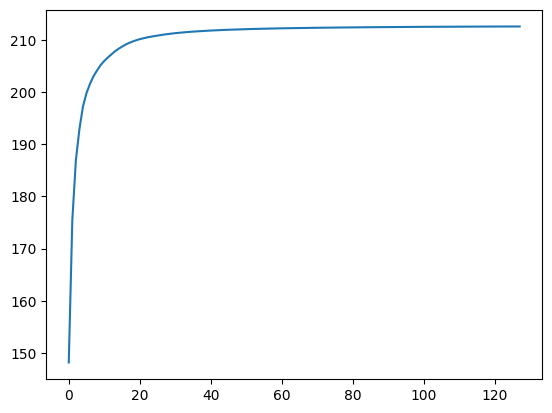

In [20]:
# plt.loglog(S.detach().cpu().numpy())
# plt.plot(S.detach().cpu().numpy())
plt.plot(torch.cumsum(S.detach().cpu(),0).numpy())
plt.show()

In [21]:
this_feature_norm_embeddings = this_feature_embeddings / this_feature_norms.unsqueeze(1).expand_as(this_feature_embeddings)

In [22]:
this_feature_intra_col_cosines = (this_feature_norm_embeddings @ this_feature_norm_embeddings.T)
this_feature_intra_col_cosines

tensor([[1.0000, 0.9683, 0.9443,  ..., 0.9448, 0.9888, 0.9731],
        [0.9683, 0.9995, 0.9932,  ..., 0.9932, 0.9912, 0.9980],
        [0.9443, 0.9932, 1.0000,  ..., 0.9995, 0.9731, 0.9888],
        ...,
        [0.9448, 0.9932, 0.9995,  ..., 1.0000, 0.9727, 0.9897],
        [0.9888, 0.9912, 0.9731,  ..., 0.9727, 1.0000, 0.9932],
        [0.9731, 0.9980, 0.9888,  ..., 0.9897, 0.9932, 0.9995]],
       device='cuda:0', dtype=torch.float16, grad_fn=<MmBackward0>)

In [23]:
import torch.nn.functional as F

def intra_column_cosines(col_emb):
    """Pairwise cosine similarities between row embeddings, for every column.

    Parameters
    ----------
    col_emb : Tensor of shape (1, T, H, embed_dim)
        Output of col_embedder, where T = train_size + test_size and H is the
        total number of column slots (including leading CLS-token slots whose
        embeddings are constant across rows).

    Returns
    -------
    Tensor of shape (H, T, T)
        cosines[h, i, j] is the cosine similarity between the embeddings of
        rows i and j at column h.
    """
    emb = col_emb[0]                               # (T, H, embed_dim)
    emb = emb.permute(1, 0, 2)                    # (H, T, embed_dim)
    emb_norm = F.normalize(emb, dim=-1)            # (H, T, embed_dim)
    return emb_norm @ emb_norm.transpose(-1, -2)   # (H, T, T)


In [24]:
all_cosines = intra_column_cosines(col_emb.detach())
print(all_cosines.shape)   # (H, T, T) = (64, 170, 170)

# Verify: column 4 should match this_feature_intra_col_cosines from above
print(torch.allclose(all_cosines[feature_id], this_feature_intra_col_cosines, atol=1e-3))


torch.Size([64, 170, 170])
True


In [26]:
def column_separation_score(col_emb, worst_case=True):
    """Pairwise angular separation score between column embedding clusters.

    For every pair of columns (h1, h2) the score is:

        score(h1, h2) = gap(h1, h2) - (spread(h1) + spread(h2)) 

    where *spread* is an angular measure of how dispersed a column's row
    embeddings are, and *gap* is the angular distance between the two columns.
    Positive scores indicate well-separated clusters (gap exceeds the combined
    spread); negative scores indicate overlap.

    Parameters
    ----------
    col_emb : Tensor of shape (1, T, H, embed_dim)
        Output of col_embedder.
    worst_case : bool, default=True
        If True, uses extremal statistics:
          - spread(h)      = acos(min intra-column cosine)   [max angular spread]
          - gap(h1, h2)    = acos(max inter-column cosine)   [min angular gap]
        If False, uses average statistics:
          - spread(h)      = acos(mean intra-column cosine)  [mean angular spread]
          - gap(h1, h2)    = acos(centroid cosine)           [centroid angular gap]

    Returns
    -------
    Tensor of shape (H, H)
        score[h1, h2] = gap[h1, h2] - (spread[h1] + spread[h2]) .
    """
    intra = intra_column_cosines(col_emb)            # (H, T, T)
    centroid_cos, max_inter_cos = inter_column_stats(col_emb)  # (H, H) each

    if worst_case:
        spread = torch.acos(intra.amin(dim=(1, 2)).clamp(-1, 1))   # (H,)
        gap    = torch.acos(max_inter_cos.clamp(-1, 1))             # (H, H)
    else:
        spread = torch.acos(intra.mean(dim=(1, 2)).clamp(-1, 1))   # (H,)
        gap    = torch.acos(centroid_cos.clamp(-1, 1))              # (H, H)

    return gap - (spread.unsqueeze(0) + spread.unsqueeze(1))         # (H, H)


In [27]:
col_emb = col_emb.detach()
score_wc  = column_separation_score(col_emb, worst_case=True)
score_avg = column_separation_score(col_emb, worst_case=False)
print(score_wc.shape, score_avg.shape)   # (64, 64) each


torch.Size([64, 64]) torch.Size([64, 64])


In [28]:
def mahalanobis_column_separation(col_emb, worst_case=True, rcond=1e-2):
    """Pairwise column separation score using symmetrised Mahalanobis distance.

    Generalises column_separation_score by replacing the angular metric with a
    Mahalanobis one that accounts for the anisotropy of each column cluster.

    For every pair of columns (h1, h2) the score is:

        score(h1, h2) = gap(h1, h2) − spread(h1) − spread(h2)

    where gap and spread are Mahalanobis distances.  Positive scores indicate
    well-separated clusters.

    Parameters
    ----------
    col_emb : Tensor of shape (1, T, H, embed_dim)
        Output of col_embedder.
    worst_case : bool, default=True
        If True:
          - spread(h)      = max  Mahalanobis distance from cluster points to centroid
          - gap(h1, h2)    = min  pairwise Mahalanobis distance between h1 and h2 points
        If False:
          - spread(h)      = mean Mahalanobis distance from cluster points to centroid
          - gap(h1, h2)    = Mahalanobis distance between centroids
    rcond : float, default=1e-2
        Tikhonov regularisation strength (relative to per-column mean variance).
        Prevents singular systems for near-constant columns (e.g. CLS tokens).

    Returns
    -------
    Tensor of shape (H, H)
        score[h1, h2] = gap[h1, h2] − spread[h1] − spread[h2].

    Notes
    -----
    Key implementation insight: after the Cholesky whitening transform
      emb_white[h, t] = L_h^{-1} @ emb[h, t]   (where Σ_h = L_h @ L_h^T)
    all Mahalanobis distances become plain Euclidean distances in whitened space.
    This lets us replace Python-level scalar loops with one triangular solve +
    one matmul per h1 iteration (~1000x speedup over a naive loop).

    The squared-distance formula ||a||²+||b||²-2a·b suffers catastrophic
    cancellation when ||a||≫||a-b|| (e.g. CLS columns with near-zero variance
    and thus huge whitened norms).  We avoid this by centring every batch by
    the whitened centroid of h1 before computing distances.
    """
    emb = col_emb[0].float().permute(1, 0, 2)   # (H, T, D)
    H, T, D = emb.shape

    means    = emb.mean(dim=1)                   # (H, D)
    centered = emb - means.unsqueeze(1)          # (H, T, D)

    # Sample covariance + Tikhonov regularisation
    covs     = centered.transpose(-1, -2) @ centered / (T - 1)               # (H, D, D)
    mean_var = covs.diagonal(dim1=-2, dim2=-1).mean(dim=-1).clamp(min=1e-8)  # (H,)
    eye      = torch.eye(D, device=emb.device, dtype=emb.dtype)
    covs_reg = covs + (rcond * mean_var).view(H, 1, 1) * eye                 # (H, D, D)

    # Cholesky: Σ_h = L_h @ L_h^T  (lower-triangular L_h)
    L = torch.linalg.cholesky(covs_reg)          # (H, D, D)

    # Self-whitened embeddings: emb_white[h, t] = L_h^{-1} @ emb[h, t]
    # Euclidean distances in this space = Mahalanobis distances under Σ_h.
    emb_white = torch.linalg.solve_triangular(
        L, emb.transpose(-1, -2), upper=False
    ).permute(0, 2, 1)                           # (H, T, D)

    # Spread: Mahalanobis radius of each cluster = Euclidean radius in whitened space
    mean_white     = emb_white.mean(dim=1, keepdim=True)   # (H, 1, D)
    centered_white = emb_white - mean_white                 # (H, T, D)
    dists_self     = centered_white.norm(dim=-1)            # (H, T)
    spread = dists_self.amax(dim=-1) if worst_case else dists_self.mean(dim=-1)  # (H,)

    if worst_case:
        # gap_1[h1, h2] = min_{t1 in h1, t2 in h2}
        #                   || L_h1^{-1} (emb[h1,t1] - emb[h2,t2]) ||
        # = min pairwise Euclidean distance between emb_white[h1] and
        #   the cross-whitened points L_h1^{-1} emb[h2].
        #
        # Loop over h1 to keep peak memory O(H·T·D) per step instead of O(H²·T·D).
        #
        # Numerical note: the squared-distance formula ||a||²+||b||²-2a·b suffers
        # catastrophic cancellation when the whitened norms are large (e.g. CLS
        # columns where Σ_h ≈ 0 → L_h^{-1} amplifies by ~1e5 → norms ~1e6, squared
        # norms ~1e12 in float32).  Fix: subtract the whitened centroid of h1 from
        # both sets of points before computing distances.  The distances are
        # translation-invariant, so the result is unchanged.
        emb_flat = emb.reshape(H * T, D)         # (H*T, D)
        gap_1    = torch.empty(H, H, device=emb.device, dtype=emb.dtype)

        for h1 in range(H):
            # Cross-whiten ALL columns' points using L[h1] in one triangular solve.
            cross = torch.linalg.solve_triangular(
                L[h1], emb_flat.T, upper=False
            ).T.view(H, T, D)                    # (H, T, D)

            # Centre by h1's whitened centroid to avoid catastrophic cancellation.
            ref     = mean_white[h1]             # (1, D)
            A_c     = emb_white[h1] - ref        # (T, D)  — centred h1 points
            cross_c = cross - ref                # (H, T, D) — centred cross-points

            sq_A = (A_c * A_c).sum(-1)                                   # (T,)
            sq_B = (cross_c * cross_c).sum(-1)                           # (H, T)
            # dots[h2, t1, t2] = A_c[t1] · cross_c[h2, t2]
            dots    = torch.matmul(A_c.unsqueeze(0), cross_c.transpose(-1, -2))  # (H, T, T)
            sq_dist = sq_A[None, :, None] + sq_B[:, None, :] - 2 * dots         # (H, T, T)
            gap_1[h1] = sq_dist.clamp(min=0).amin(dim=(-1, -2)).sqrt()          # (H,)

        gap = (gap_1 + gap_1.T) / 2              # symmetrise

    else:
        # gap[h1, h2] = symmetrised centroid Mahalanobis distance
        #             = (||L_h1^{-1}(μ_h2-μ_h1)|| + ||L_h2^{-1}(μ_h1-μ_h2)||) / 2
        # delta[h1, h2] = μ_h2 - μ_h1  (in original space, no cancellation issue)
        delta   = means.unsqueeze(0) - means.unsqueeze(1)   # (H, H, D)
        sol_gap = torch.linalg.solve_triangular(
            L, delta.permute(0, 2, 1), upper=False
        )                                        # (H, D, H); [h1,:,h2] = L_h1^{-1}(μ_h2-μ_h1)
        d_gap = sol_gap.norm(dim=1)              # (H, H)
        gap   = (d_gap + d_gap.T) / 2

    return gap - spread.unsqueeze(0) - spread.unsqueeze(1)   # (H, H)


In [29]:
import time

t0 = time.time()
mah_wc  = mahalanobis_column_separation(col_emb, worst_case=True)
mah_avg = mahalanobis_column_separation(col_emb, worst_case=False)
print(f"Elapsed: {time.time() - t0:.2f}s")
print('shape (wc, avg):', mah_wc.shape, mah_avg.shape)

# Symmetry
print('symmetric (wc) :', torch.allclose(mah_wc,  mah_wc.T,  atol=1e-3))
print('symmetric (avg):', torch.allclose(mah_avg, mah_avg.T, atol=1e-3))

# Diagonal: gap=0 (cluster vs itself) → score = -2·spread ≤ 0
print('diagonal ≤ 0 (wc) :', (mah_wc.diagonal()  <= 1e-3).all().item())
print('diagonal ≤ 0 (avg):', (mah_avg.diagonal() <= 1e-3).all().item())

# CLS columns (0-3) have zero intra-cluster variance; regularisation keeps
# them finite but their scores are not physically meaningful → excluded from plots.
print('CLS diagonal (wc) :', [round(x, 4) for x in mah_wc.diagonal()[:4].tolist()])

# Feature columns should have strongly negative diagonals (large spread, zero self-gap)
print('feature diagonal (wc):', [round(x, 2) for x in mah_wc.diagonal()[4:12].tolist()])
print('feature diagonal (avg):', [round(x, 2) for x in mah_avg.diagonal()[4:12].tolist()])


Elapsed: 0.12s
shape (wc, avg): torch.Size([64, 64]) torch.Size([64, 64])
symmetric (wc) : True
symmetric (avg): True
diagonal ≤ 0 (wc) : True
diagonal ≤ 0 (avg): True
CLS diagonal (wc) : [-0.017, -0.0199, -0.0201, -0.0183]
feature diagonal (wc): [-17.65, -25.2, -25.88, -21.97, -17.36, -24.6, -20.78, -24.13]
feature diagonal (avg): [-8.28, -8.7, -9.18, -8.64, -8.68, -9.22, -8.69, -8.56]


In [30]:
score_wc

tensor([[ 0.0000,  1.2227,  1.3311,  ...,  0.8799,  0.8506,  0.9189],
        [ 1.2227, -0.0312,  1.2402,  ...,  0.8779,  0.8643,  0.9277],
        [ 1.3311,  1.2402,  0.0000,  ...,  0.9424,  0.9258,  0.9629],
        ...,
        [ 0.8799,  0.8779,  0.9424,  ..., -1.2578, -0.7856, -0.6060],
        [ 0.8506,  0.8643,  0.9258,  ..., -0.7856, -1.3203, -0.5205],
        [ 0.9189,  0.9277,  0.9629,  ..., -0.6060, -0.5205, -1.2109]],
       device='cuda:0', dtype=torch.float16)

In [31]:
score_avg

tensor([[ 0.0000,  1.2227,  1.3311,  ...,  1.2412,  1.2402,  1.2305],
        [ 1.2227, -0.0312,  1.2402,  ...,  1.2471,  1.2559,  1.2520],
        [ 1.3311,  1.2402,  0.0000,  ...,  1.3037,  1.3193,  1.2734],
        ...,
        [ 1.2412,  1.2471,  1.3037,  ..., -0.5464, -0.0322,  0.0664],
        [ 1.2402,  1.2559,  1.3193,  ..., -0.0322, -0.5190,  0.1855],
        [ 1.2305,  1.2520,  1.2734,  ...,  0.0664,  0.1855, -0.5703]],
       device='cuda:0', dtype=torch.float16)

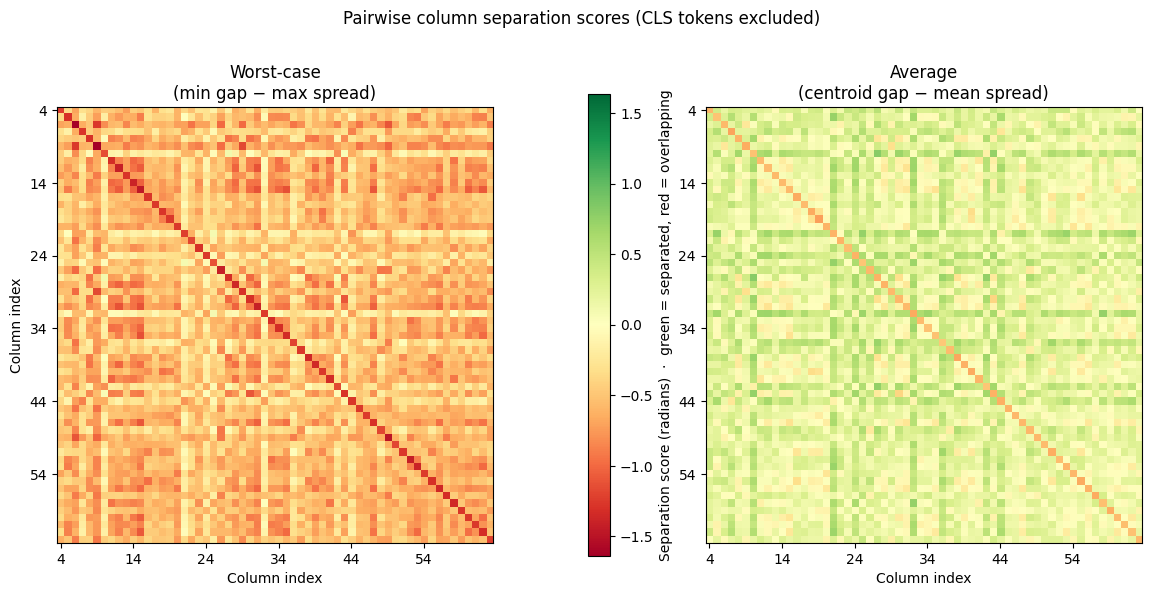

In [32]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 0.05, 1], wspace=0.32)
ax1 = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

data_wc  = score_wc[4:, 4:].float().cpu()
data_avg = score_avg[4:, 4:].float().cpu()

# Symmetric colour range centred at 0 so colours are directly comparable
vabs = max(data_wc.abs().max(), data_avg.abs().max()).item()

kw = dict(vmin=-vabs, vmax=vabs, cmap='RdYlGn', aspect='equal')
im1 = ax1.imshow(data_wc,  **kw)
im2 = ax2.imshow(data_avg, **kw)

# Tick labels show the original column indices (first 4 are CLS tokens)
ticks = list(range(0, 60, 10))
tick_labels = [str(i + 4) for i in ticks]
for ax in (ax1, ax2):
    ax.set_xticks(ticks); ax.set_xticklabels(tick_labels)
    ax.set_yticks(ticks); ax.set_yticklabels(tick_labels)
    ax.set_xlabel('Column index')
ax1.set_ylabel('Column index')

ax1.set_title('Worst-case\n(min gap − max spread)')
ax2.set_title('Average\n(centroid gap − mean spread)')

fig.colorbar(im1, cax=cax,
             label='Separation score (radians)  ·  green = separated, red = overlapping')
fig.suptitle('Pairwise column separation scores (CLS tokens excluded)', y=1.02)
plt.show()


In [33]:
mah_wc

tensor([[-1.6996e-02,  1.0002e+05,  1.0859e+05,  ...,  5.0499e+05,
          4.9669e+05,  4.9746e+05],
        [ 1.0002e+05, -1.9888e-02,  1.0680e+05,  ...,  5.0667e+05,
          4.9859e+05,  4.9890e+05],
        [ 1.0859e+05,  1.0680e+05, -2.0142e-02,  ...,  5.0798e+05,
          5.0101e+05,  5.0051e+05],
        ...,
        [ 5.0499e+05,  5.0667e+05,  5.0798e+05,  ..., -2.4336e+01,
          2.5788e+02,  3.0501e+02],
        [ 4.9669e+05,  4.9859e+05,  5.0101e+05,  ...,  2.5788e+02,
         -2.3242e+01,  3.6680e+02],
        [ 4.9746e+05,  4.9890e+05,  5.0051e+05,  ...,  3.0501e+02,
          3.6680e+02, -2.2853e+01]], device='cuda:0')

In [34]:
(mah_wc / mah_avg)[4:,4:]

tensor([[2.1314, 0.9637, 0.9650,  ..., 0.9569, 0.9684, 0.9537],
        [0.9637, 2.8985, 0.9559,  ..., 0.9184, 0.9282, 0.9547],
        [0.9650, 0.9559, 2.8182,  ..., 0.9531, 0.9615, 0.9364],
        ...,
        [0.9569, 0.9184, 0.9531,  ..., 2.7059, 0.9373, 0.9494],
        [0.9684, 0.9282, 0.9615,  ..., 0.9373, 2.5801, 0.9556],
        [0.9537, 0.9547, 0.9364,  ..., 0.9494, 0.9556, 2.4852]],
       device='cuda:0')

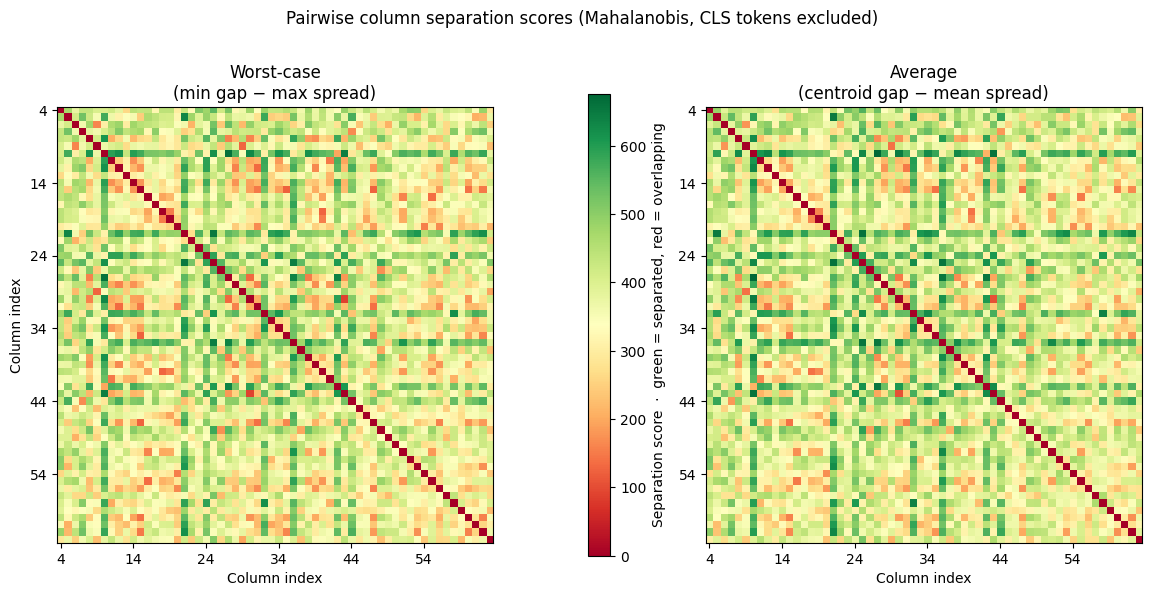

In [35]:
fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1, 0.05, 1], wspace=0.32)
ax1 = fig.add_subplot(gs[0])
cax = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])

data_wc  = mah_wc[4:, 4:].float().cpu()
data_avg = mah_avg[4:, 4:].float().cpu()

# Symmetric colour range centred at 0 so colours are directly comparable
vabs = max(data_wc.abs().max(), data_avg.abs().max()).item()

kw = dict(vmin=0, vmax=vabs, cmap='RdYlGn', aspect='equal')
im1 = ax1.imshow(data_wc,  **kw)
im2 = ax2.imshow(data_avg, **kw)

# Tick labels show the original column indices (first 4 are CLS tokens)
ticks = list(range(0, 60, 10))
tick_labels = [str(i + 4) for i in ticks]
for ax in (ax1, ax2):
    ax.set_xticks(ticks); ax.set_xticklabels(tick_labels)
    ax.set_yticks(ticks); ax.set_yticklabels(tick_labels)
    ax.set_xlabel('Column index')
ax1.set_ylabel('Column index')

ax1.set_title('Worst-case\n(min gap − max spread)')
ax2.set_title('Average\n(centroid gap − mean spread)')

fig.colorbar(im1, cax=cax,
             label='Separation score  ·  green = separated, red = overlapping')
fig.suptitle('Pairwise column separation scores (Mahalanobis, CLS tokens excluded)', y=1.02)
plt.show()